In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [10]:
data_path = "../data/"
all_files = glob.glob(os.path.join(data_path, "*.csv"))

# Correct 12 columns based on raw file inspection
col_names = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag']

df_list = []
for file in all_files:
    try:
        temp_df = pd.read_csv(
            file,
            header=None,           # no header row in file
            names=col_names,       # assign our column names
            on_bad_lines='skip'    # skip corrupted rows
        )
        temp_df['source_file'] = os.path.basename(file)
        df_list.append(temp_df)
        print(f"✅ Loaded {os.path.basename(file)}: {len(temp_df):,} rows")
    except Exception as e:
        print(f"❌ Failed: {os.path.basename(file)} → {e}")

df = pd.concat(df_list, ignore_index=True)
print(f"\n📊 Total combined rows: {len(df):,}")
print(f"📋 Columns: {list(df.columns)}")
print(f"\n🏷️ Flag values: {df['Flag'].unique()}")

✅ Loaded DoS_dataset.csv: 3,665,771 rows
✅ Loaded Fuzzy_dataset.csv: 3,838,860 rows
✅ Loaded gear_dataset.csv: 4,443,142 rows
✅ Loaded normal_run_data.csv: 988,872 rows
✅ Loaded RPM_dataset.csv: 4,621,702 rows

📊 Total combined rows: 17,558,347
📋 Columns: ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'Flag', 'source_file']

🏷️ Flag values: ['R' nan 'T']


In [11]:
print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== FLAG DISTRIBUTION ===")
print(df['Flag'].value_counts())

print(f"\n=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== DATASET SHAPE ===")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")

=== FIRST 5 ROWS ===
           Timestamp    ID  DLC  D0  D1  D2  D3  D4  D5  D6  D7 Flag  \
0  1478198376.389427  0316  8.0  05  21  68  09  21  21  00  6f    R   
1  1478198376.389636  018f  8.0  fe  5b  00  00  00  3c  00  00    R   
2  1478198376.389864  0260  8.0  19  21  22  30  08  8e  6d  3a    R   
3  1478198376.390096  02a0  8.0  64  00  9a  1d  97  02  bd  00    R   
4  1478198376.390333  0329  8.0  40  bb  7f  14  11  20  00  14    R   

       source_file  
0  DoS_dataset.csv  
1  DoS_dataset.csv  
2  DoS_dataset.csv  
3  DoS_dataset.csv  
4  DoS_dataset.csv  

=== FLAG DISTRIBUTION ===
Flag
R    14037293
T     2331517
Name: count, dtype: int64

=== MISSING VALUES ===
Timestamp            0
ID              988872
DLC             988872
D0              988872
D1              988872
D2              988872
D3             1136083
D4             1136083
D5             1136083
D6             1189534
D7             1189537
Flag           1189537
source_file          0
dtype: int6

In [12]:
# Drop rows where Flag is missing
df = df.dropna(subset=['Flag'])

# Strip whitespace from Flag and ID columns
df['Flag'] = df['Flag'].str.strip()
df['ID'] = df['ID'].str.strip()

# Convert Timestamp to float
df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')
df = df.dropna(subset=['Timestamp'])

print("=== CLEANED FLAG VALUES ===")
print(df['Flag'].value_counts())

# R = Normal traffic, T = Attack traffic
print("\n✅ R = Normal | T = Attack")
print(f"Normal rows : {len(df[df['Flag'] == 'R']):,}")
print(f"Attack rows : {len(df[df['Flag'] == 'T']):,}")

=== CLEANED FLAG VALUES ===
Flag
R    14037293
T     2331517
Name: count, dtype: int64

✅ R = Normal | T = Attack
Normal rows : 14,037,293
Attack rows : 2,331,517


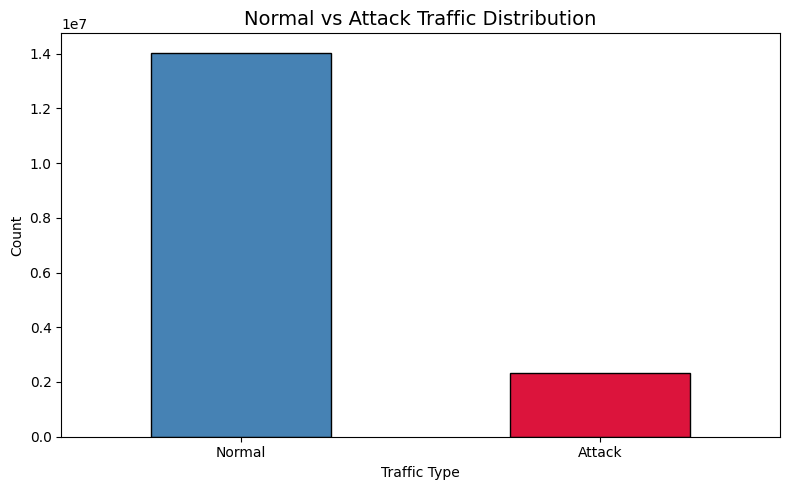

✅ Chart saved!


In [13]:
flag_labels = df['Flag'].map({'R': 'Normal', 'T': 'Attack'})

plt.figure(figsize=(8, 5))
flag_labels.value_counts().plot(
    kind='bar',
    color=['steelblue', 'crimson'],
    edgecolor='black'
)
plt.title('Normal vs Attack Traffic Distribution', fontsize=14)
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/label_distribution.png')
plt.show()
print("✅ Chart saved!")

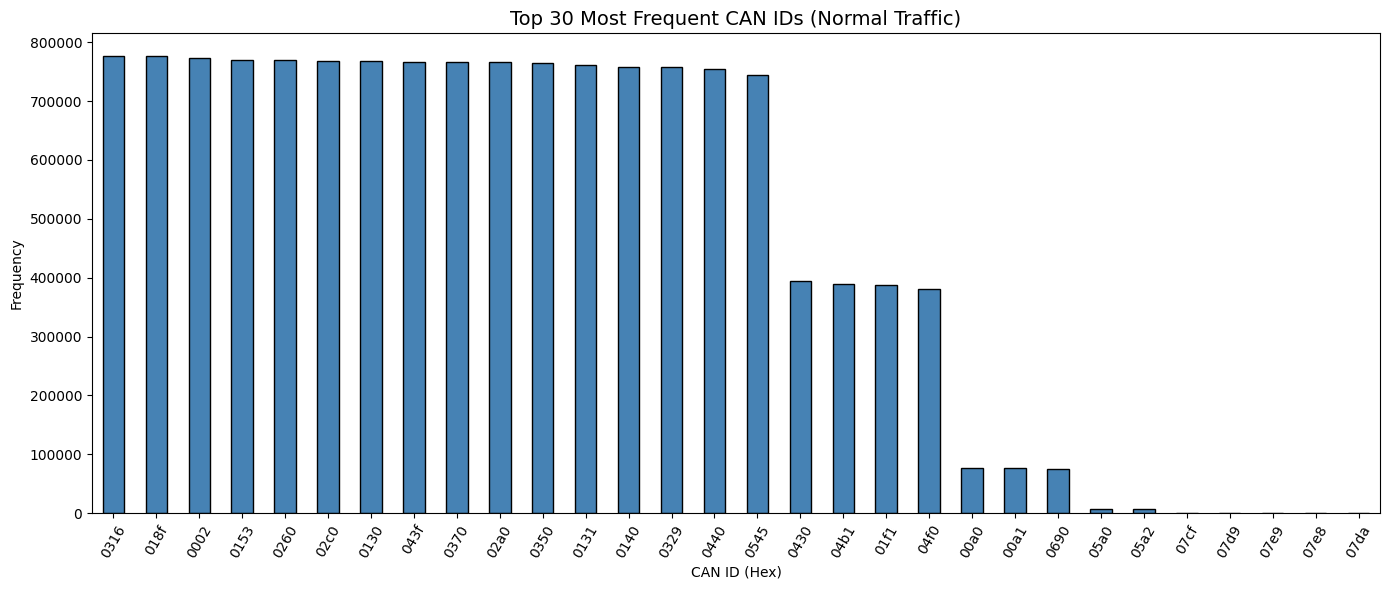

✅ Chart saved!


In [14]:
plt.figure(figsize=(14, 6))
top_ids = df[df['Flag'] == 'R']['ID'].value_counts().head(30)
top_ids.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 30 Most Frequent CAN IDs (Normal Traffic)', fontsize=14)
plt.xlabel('CAN ID (Hex)')
plt.ylabel('Frequency')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('../data/can_id_frequency.png')
plt.show()
print("✅ Chart saved!")

In [15]:
df_normal = df[df['Flag'] == 'R'].copy()

print(f"Total rows      : {len(df):,}")
print(f"Normal rows     : {len(df_normal):,}")
print(f"Attack rows     : {len(df[df['Flag'] == 'T']):,}")
print(f"Normal %        : {len(df_normal)/len(df)*100:.1f}%")

Total rows      : 16,368,810
Normal rows     : 14,037,293
Attack rows     : 2,331,517
Normal %        : 85.8%


In [4]:
import pandas as pd
import glob
import os
import gc

data_path = "../data/"
all_files = glob.glob(os.path.join(data_path, "*.csv"))

col_names = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3',
             'D4', 'D5', 'D6', 'D7', 'Flag']

output_normal = "../data/normal_traffic.csv"

# Remove old file if exists
if os.path.exists(output_normal):
    os.remove(output_normal)

header_written = False
total_normal = 0

print("Extracting normal traffic...\n")

for file in all_files:
    # Skip already processed files
    if 'normal_traffic' in file or 'attack_traffic' in file:
        print(f"⏭️  Skipping: {os.path.basename(file)}")
        continue

    print(f"📂 Processing: {os.path.basename(file)}")

    for chunk in pd.read_csv(
        file,
        header=None,
        names=col_names,
        chunksize=100_000,
        on_bad_lines='skip'
    ):
        # Fix: force Flag to string before filtering
        chunk['Flag'] = chunk['Flag'].astype(str).str.strip()
        normal_chunk = chunk[chunk['Flag'] == 'R'].copy()

        if len(normal_chunk) > 0:
            normal_chunk.to_csv(
                output_normal,
                mode='a',
                header=not header_written,
                index=False
            )
            header_written = True
            total_normal += len(normal_chunk)

        del chunk, normal_chunk
        gc.collect()

    print(f"  ✅ Done — {total_normal:,} normal rows saved so far\n")

print(f"🎉 normal_traffic.csv saved!")
print(f"📊 Total normal rows: {total_normal:,}")

Extracting normal traffic...

📂 Processing: DoS_dataset.csv
  ✅ Done — 3,047,062 normal rows saved so far

📂 Processing: Fuzzy_dataset.csv
  ✅ Done — 6,306,239 normal rows saved so far

📂 Processing: gear_dataset.csv
  ✅ Done — 10,111,964 normal rows saved so far

📂 Processing: normal_run_data.csv
  ✅ Done — 10,111,964 normal rows saved so far

⏭️  Skipping: normal_traffic.csv
📂 Processing: RPM_dataset.csv
  ✅ Done — 14,037,293 normal rows saved so far

🎉 normal_traffic.csv saved!
📊 Total normal rows: 14,037,293


In [5]:
import gc
import os
import pandas as pd
import numpy as np

output_aug = "../data/normal_traffic_augmented.csv"
normal_path = "../data/normal_traffic.csv"

if os.path.exists(output_aug):
    os.remove(output_aug)

CHUNK_SIZE = 100_000
header_written = False
total_written = 0

print("=== Starting Chunk-Based Augmentation ===\n")

for round_idx in range(4):
    print(f"📦 Round {round_idx + 1}/4 ...")
    chunk_count = 0

    for chunk in pd.read_csv(normal_path, chunksize=CHUNK_SIZE):
        if round_idx == 0:
            out = chunk.copy()
        else:
            out = chunk.copy()

            # Strategy 1: Timestamp noise
            noise = np.random.uniform(-0.0005, 0.0005, size=len(out))
            out['Timestamp'] = pd.to_numeric(
                out['Timestamp'], errors='coerce'
            ) + noise

            # Strategy 2: Duplicate rare IDs
            id_counts = out['ID'].value_counts()
            rare_ids = id_counts[
                id_counts < id_counts.quantile(0.25)
            ].index
            rare_rows = out[out['ID'].isin(rare_ids)]
            if len(rare_rows) > 0:
                extra = rare_rows.sample(frac=0.2, replace=True)
                out = pd.concat([out, extra], ignore_index=True)

            # Strategy 3: Shuffle
            out = out.sample(frac=1).reset_index(drop=True)

        out.to_csv(
            output_aug,
            mode='a',
            header=not header_written,
            index=False
        )
        header_written = True
        total_written += len(out)
        chunk_count += 1

        del out, chunk
        gc.collect()

    print(f"  ✅ Round {round_idx + 1} done — {chunk_count} chunks processed")

original_size = 14_037_293  # from previous step output

print(f"\n🎉 Augmentation Complete!")
print(f"📊 Original rows  : {original_size:,}")
print(f"📊 Augmented rows : {total_written:,}")
print(f"📈 Expansion      : {total_written / original_size:.1f}x")
print(f"💾 Saved to       : {output_aug}")

=== Starting Chunk-Based Augmentation ===

📦 Round 1/4 ...
  ✅ Round 1 done — 141 chunks processed
📦 Round 2/4 ...
  ✅ Round 2 done — 141 chunks processed
📦 Round 3/4 ...
  ✅ Round 3 done — 141 chunks processed
📦 Round 4/4 ...
  ✅ Round 4 done — 141 chunks processed

🎉 Augmentation Complete!
📊 Original rows  : 14,037,293
📊 Augmented rows : 56,441,183
📈 Expansion      : 4.0x
💾 Saved to       : ../data/normal_traffic_augmented.csv


In [6]:
import pandas as pd
import glob
import os
import gc

data_path = "../data/"
all_files = glob.glob(os.path.join(data_path, "*.csv"))

col_names = ['Timestamp', 'ID', 'DLC', 'D0', 'D1', 'D2', 'D3',
             'D4', 'D5', 'D6', 'D7', 'Flag']

output_attacks = "../data/attack_traffic.csv"

if os.path.exists(output_attacks):
    os.remove(output_attacks)

header_written = False
total_attacks = 0

print("Extracting attack traffic...\n")

for file in all_files:
    if 'normal_traffic' in file or 'attack_traffic' in file:
        print(f"⏭️  Skipping: {os.path.basename(file)}")
        continue

    print(f"📂 Processing: {os.path.basename(file)}")

    for chunk in pd.read_csv(
        file,
        header=None,
        names=col_names,
        chunksize=100_000,
        on_bad_lines='skip'
    ):
        chunk['Flag'] = chunk['Flag'].astype(str).str.strip()
        attack_chunk = chunk[chunk['Flag'] == 'T'].copy()

        if len(attack_chunk) > 0:
            attack_chunk.to_csv(
                output_attacks,
                mode='a',
                header=not header_written,
                index=False
            )
            header_written = True
            total_attacks += len(attack_chunk)

        del chunk, attack_chunk
        gc.collect()

    print(f"  ✅ Done — {total_attacks:,} attack rows saved so far\n")

print(f"🎉 attack_traffic.csv saved!")
print(f"📊 Total attack rows: {total_attacks:,}")

Extracting attack traffic...

📂 Processing: DoS_dataset.csv
  ✅ Done — 587,521 attack rows saved so far

📂 Processing: Fuzzy_dataset.csv
  ✅ Done — 1,079,368 attack rows saved so far

📂 Processing: gear_dataset.csv
  ✅ Done — 1,676,620 attack rows saved so far

📂 Processing: normal_run_data.csv
  ✅ Done — 1,676,620 attack rows saved so far

⏭️  Skipping: normal_traffic.csv
⏭️  Skipping: normal_traffic_augmented.csv
📂 Processing: RPM_dataset.csv
  ✅ Done — 2,331,517 attack rows saved so far

🎉 attack_traffic.csv saved!
📊 Total attack rows: 2,331,517
